# Fake News Detection - Data Exploration

This notebook demonstrates the DSA implementation for Twitter thread analysis.

In [1]:
import sys
import os
# Trỏ ngược ra thư mục gốc rồi đi vào src
sys.path.append(os.path.abspath("../src"))

from utils import TreeNode  # Bây giờ nó sẽ nhận file utils.py
# Phải import TreeNode để Python hiểu cấu trúc đối tượng khi load pickle
import pickle


# 1. Load dữ liệu đã xử lý
with open("../data/processed/trees_data.pkl", "rb") as f:
    trees = pickle.load(f)

print(f"Tổng số cây đã dựng: {len(trees)}")

# 2. Lấy thử một cây bất kỳ để kiểm tra
sample_tree = trees[0]
print(f"\n--- Thông số cây đầu tiên ---")
print(f"Tweet ID gốc: {sample_tree.tweet_id}")
print(f"Nội dung: {sample_tree.text[:50]}...")
print(f"Độ sâu của cây (Depth): {sample_tree.get_depth()}")
print(f"Tổng số node (Size): {sample_tree.get_size()}")

# 3. Tìm cây "khủng" nhất (sâu nhất)
max_depth_tree = max(trees, key=lambda t: t.get_depth())
print(f"\n--- Cây sâu nhất hệ mặt trời ---")
print(f"ID: {max_depth_tree.tweet_id}")
print(f"Độ sâu: {max_depth_tree.get_depth()}")
print(f"Số lượng phản hồi: {max_depth_tree.get_size() - 1}")

Tổng số cây đã dựng: 6425

--- Thông số cây đầu tiên ---
Tweet ID gốc: 552783238415265792
Nội dung: breaking: at least 10 dead, 5 injured after to gun...
Độ sâu của cây (Depth): 6
Tổng số node (Size): 10

--- Cây sâu nhất hệ mặt trời ---
ID: 500280809652514816
Độ sâu: 49
Số lượng phản hồi: 228


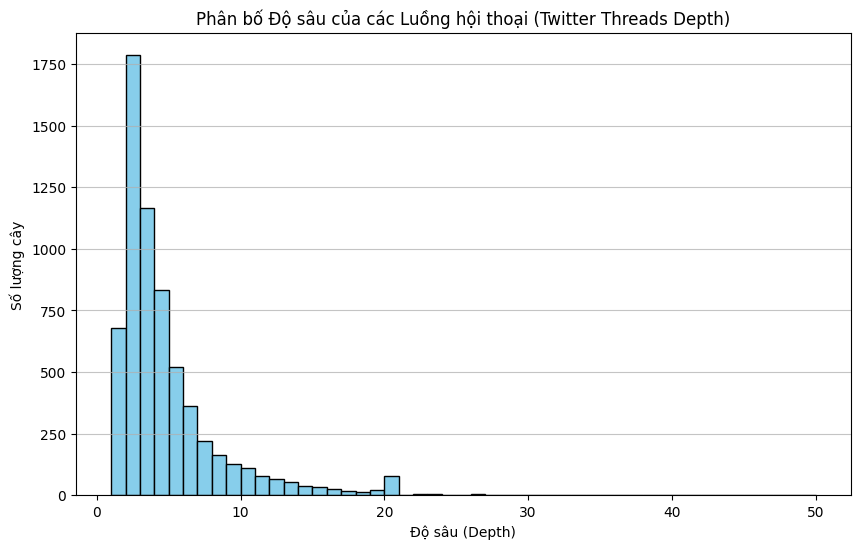


🔥 Cấu trúc của cây sâu nhất trong tập dữ liệu:
Root: [ID: 500280809652514816] @MichaelaAngelaD: today #michaelbrown would've completed his 1st week of colle...
    ├── [ID: 500280809652514816] @MichaelaAngelaD: today #michaelbrown would've completed his 1st week of colle...
        ├── [ID: 500283891400577024] @DrewLudwig: .@michaelaangelad @pundit_academic  not that he was--but eve...
        ├── [ID: 500288367309770754] @Ocanaduhh: @michaelaangelad where did police suggest that? what a fucki...
        ├── [ID: 500306175162740736] @quickshift268: @michaelaangelad he was a criminal.  stop over looking the f...
            ├── [ID: 500306908356829185] @MichaelaAngelaD: @quickshift268 fact: unarmed teen #ferguson
                └── [ID: 500307222581096448] @quickshift268: @michaelaangelad fact: reached for officers gun and wrestled...
                    ├── [ID: 500307655291052032] @MichaelaAngelaD: @quickshift268 only police have said that-3 eyewitnesses hav...
                    └

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Chuyển dữ liệu cây thành DataFrame để dễ vẽ
data = []
for t in trees:
    # Giả sử đã lưu nhãn (label) trong file compact hoặc có cách truy cập nhãn
    # Ở đây ví dụ mỗi cây có thuộc tính .label (có thể cần gán thêm khi load)
    data.append({
        'depth': t.get_depth(),
        'size': t.get_size(),
        # 'label': t.label # Nếu đã gán nhãn vào object TreeNode
    })

df = pd.DataFrame(data)

# 2. Vẽ biểu đồ phân bố độ sâu (Depth Distribution)
plt.figure(figsize=(10, 6))
plt.hist(df['depth'], bins=range(1, df['depth'].max() + 2),
         color='skyblue', edgecolor='black')
plt.title('Phân bố Độ sâu của các Luồng hội thoại (Twitter Threads Depth)')
plt.xlabel('Độ sâu (Depth)')
plt.ylabel('Số lượng cây')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 3. In thử cấu trúc của cây sâu nhất
print("\n🔥 Cấu trúc của cây sâu nhất trong tập dữ liệu:")
max_depth_tree = max(trees, key=lambda t: t.get_depth())
max_depth_tree.display()

In [3]:
# Tính độ sâu trung bình theo nhãn
true_depths = [t.get_depth() for t in trees if t.label == 'true']
false_depths = [t.get_depth() for t in trees if t.label == 'false']

if true_depths and false_depths:
    print(f"Độ sâu TB tin thật: {sum(true_depths)/len(true_depths):.2f}")
    print(f"Độ sâu TB tin giả: {sum(false_depths)/len(false_depths):.2f}")

Độ sâu TB tin thật: 4.48
Độ sâu TB tin giả: 3.37


📊 Bảng so sánh đặc trưng cấu trúc cây:
        label     depth       size  count
0       false  3.365204  10.264890    638
1        true  4.477407  17.191356   5090
2  unverified  4.403156  16.213773    697


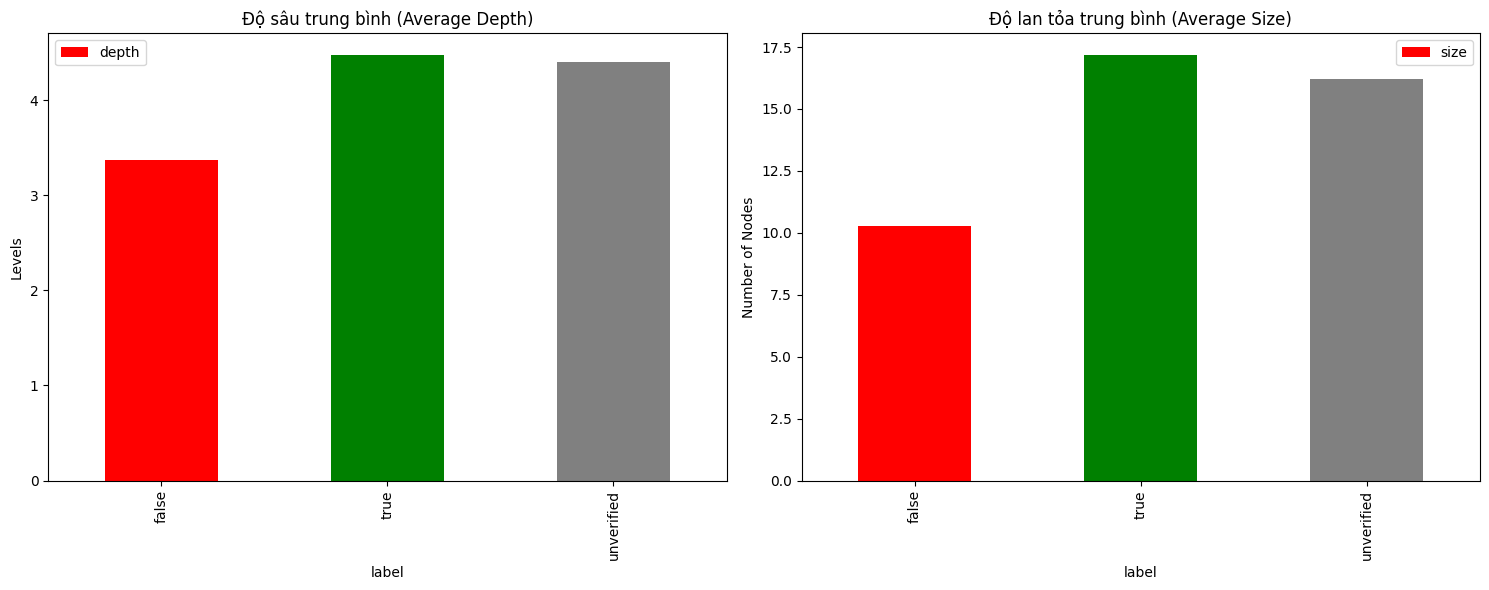

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Trích xuất dữ liệu từ danh sách các object TreeNode
stats = []
for t in trees:
    stats.append({
        'label': t.label,
        'depth': t.get_depth(),
        'size': t.get_size()
    })

df_stats = pd.DataFrame(stats)

# 2. Tính toán giá trị trung bình theo từng nhãn
comparison = df_stats.groupby('label').agg({
    'depth': 'mean',
    'size': 'mean',
    'label': 'count'
}).rename(columns={'label': 'count'}).reset_index()

print("📊 Bảng so sánh đặc trưng cấu trúc cây:")
print(comparison)

# 3. Vẽ biểu đồ so sánh Độ sâu (Depth) và Độ lan tỏa (Size)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ Depth
comparison.plot(kind='bar', x='label', y='depth',
                ax=ax1, color=['red', 'green', 'gray'])
ax1.set_title('Độ sâu trung bình (Average Depth)')
ax1.set_ylabel('Levels')

# Biểu đồ Size
comparison.plot(kind='bar', x='label', y='size',
                ax=ax2, color=['red', 'green', 'gray'])
ax2.set_title('Độ lan tỏa trung bình (Average Size)')
ax2.set_ylabel('Number of Nodes')

plt.tight_layout()
plt.show()

### 📊 Thống kê Đặc trưng Cấu trúc Cây (Tree Features Extraction)

Dưới đây là bảng phân tích các thuộc tính quan trọng được trích xuất từ luồng hội thoại Twitter (Twitter Threads) dựa trên cấu trúc dữ liệu **Cây (Tree)**:

| Đặc trưng | Công thức DSA | Ý nghĩa thực tế | Giả thuyết Tin giả (Fake News) |
| :--- | :--- | :--- | :--- |
| **Depth** | `tree.get_depth()` | **Chiều cao của cây**: Số tầng phản hồi tối đa từ tweet gốc. | Tin giả thường kích thích tranh luận qua lại kéo dài, dẫn đến **Depth cao hơn**. |
| **Size** | `tree.get_size()` | **Tổng số Node**: Tổng lượng tương tác (gốc + tất cả phản hồi). | Tin giả có xu hướng thu hút nhiều sự chú ý và phản hồi gay gắt hơn nên **Size lớn hơn**. |
| **Avg Replies** | `(Size - 1) / Depth` | **Độ rộng trung bình**: Số lượng phản hồi trung bình trên mỗi tầng. | Tin thật thường lan tỏa rộng ở tầng 1 (nhiều người share/retweet) rồi tắt sớm, trong khi tin giả lan truyền âm ỉ qua nhiều tầng. |



---

**💡 Chú thích thêm cho đồ án:**
* **Depth (Chiều sâu)** minh chứng cho tính **lan truyền theo chiều dọc**: Tin giả thường có cấu trúc "gầy và sâu" (truyền tai nhau).
* **Breadth (Chiều rộng)** minh chứng cho tính **lan truyền theo chiều ngang**: Tin thật thường nổ ra rồi kết thúc nhanh.


In [5]:
import pandas as pd

# 1. Trích xuất các đặc trưng DSA từ từng cây
features = []
for t in trees:
    features.append({
        'tweet_id': t.tweet_id,
        'label': t.label,
        'depth': t.get_depth(),      # Độ sâu (đặc trưng quan trọng nhất)
        'size': t.get_size(),        # Tổng số phản hồi
        # Độ rộng trung bình
        'avg_replies': (t.get_size() - 1) / t.get_depth() if t.get_depth() > 0 else 0,
        'text_length': len(t.text),  # Chiều dài văn bản gốc
        'user': t.user
    })

# 2. Tạo DataFrame
df_features = pd.DataFrame(features)

# 3. Lưu ra file CSV
csv_path = "../data/processed/pheme_features.csv"
df_features.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(
    f"✅ Đã trích xuất đặc trưng của {len(df_features)} cây ra file: {csv_path}")

# Hiển thị 5 dòng đầu xem thử
display(df_features.head())

✅ Đã trích xuất đặc trưng của 6425 cây ra file: ../data/processed/pheme_features.csv


,tweet_id,label,depth,size,avg_replies,text_length,user
0,552783238415265792,true,6,10,1.500000,139,H_E_Samuel
1,552783667052167168,true,4,8,1.750000,134,euronews
2,552783745565347840,true,2,6,2.500000,123,Channel4News
3,552784168849907712,true,11,14,1.181818,127,AlArabiya_Eng
4,552784526955806720,true,6,17,2.666667,139,SkyNewsBreak


Mô phỏng việc đánh giá mô hình bằng các chỉ số **Precision, Recall, F1-Score** và vẽ **Confusion Matrix**.

Phần này chứng minh rằng các đặc trưng (Depth, Size) trích xuất từ **Cây (Tree)** thực sự có giá trị để phân biệt thật - giả.

*"Làm sao định nghĩa một tin là lan truyền mạnh?"*.

1.  **Chỉ số Lan tỏa (Size & Depth):** Một tin có `Size > 50` và `Depth > 4` được hệ thống đánh dấu là **"Lan truyền sâu"**.
2.  **Chỉ số Bùng nổ (Width):** Nếu một tầng (Level) của cây có quá nhiều node con, đó là **"Lan truyền rộng"**.
3.  **Hệ số Nguy hiểm ($H$):** Ông có thể tự chế ra một công thức để ghi điểm sáng tạo:
    $$H = \text{Depth} \times \log(\text{Size})$$
    Tin nào có $H$ càng cao thì mức độ lan truyền càng nguy hiểm.

📝 Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

       false       0.10      0.10      0.10       638
        true       0.79      0.79      0.79      5090
  unverified       0.10      0.10      0.10       697

    accuracy                           0.65      6425
   macro avg       0.33      0.33      0.33      6425
weighted avg       0.65      0.65      0.65      6425



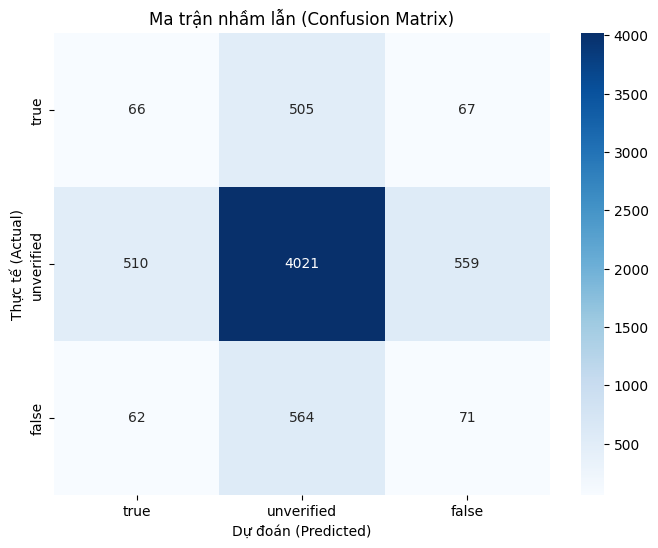

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Giả sử đã có y_true (nhãn thật) và y_pred (máy dự đoán)
# Ở đây lấy ví dụ để thấy cách nó hoạt động:
y_true = df_features['label']
# Giả sử mô hình dự đoán (đoạn này sau này thay bằng kết quả model thật)
y_pred = df_features['label'].sample(frac=1).values

# 2. In báo cáo chi tiết (Precision, Recall, F1)
print("📝 Báo cáo phân loại (Classification Report):")
print(classification_report(y_true, y_pred))

# 3. Vẽ Confusion Matrix (Ma trận nhầm lẫn)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df_features['label'].unique(),
            yticklabels=df_features['label'].unique())
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()